In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/bit_sathy_carbon_daily_3yr.csv")

In [3]:
df.head()

,date,day_of_week,is_weekend,month,day_of_year,academic_phase,is_holiday,avg_temp_c,max_temp_c,rainfall_mm,...,hostellers_present,day_scholars_present,electricity_kwh,diesel_l,water_l,waste_kg,lpg_kg,solar_kwh_generated,carbon_kg,carbon_kg_next_day
0,2023-01-01,6,1,1,1,winter_break,1,22.9,29.3,0.0,...,680,82,5539.0,13.9,98883.7,255.8,14.23,840.8,4219.0,4239.3
1,2023-01-02,0,0,1,2,winter_break,0,23.7,30.3,0.0,...,680,82,5583.0,2.7,103667.1,246.1,15.38,811.6,4239.3,4508.5
2,2023-01-03,1,0,1,3,winter_break,0,23.0,29.4,0.0,...,680,82,6054.5,0.0,120568.9,239.0,13.98,884.5,4508.5,8811.3
3,2023-01-04,2,0,1,4,even_sem_classes,0,24.6,32.0,0.0,...,3298,3854,9446.3,0.0,596178.1,1799.9,87.10,818.9,8811.3,9819.5
4,2023-01-05,3,0,1,5,even_sem_classes,0,23.5,29.0,0.0,...,3298,3854,10087.4,0.0,621113.4,1812.2,86.38,964.7,9819.5,9841.5


In [4]:
df['academic_phase'].value_counts()

academic_phase
even_sem_classes    394
odd_sem_classes     333
summer_break        183
even_sem_exam        78
odd_sem_exam         63
winter_break         44
Name: count, dtype: int64

In [5]:
df['academic_phase'].replace("even_sem_classes" , 0 , inplace=True)
df['academic_phase'].replace("odd_sem_classes" , 1 , inplace=True)
df['academic_phase'].replace("summer_break" , 2 , inplace=True)
df['academic_phase'].replace("even_sem_exam" , 3 , inplace=True)
df['academic_phase'].replace("odd_sem_exam" , 4 , inplace=True)
df['academic_phase'].replace("winter_break" , 5 , inplace=True)

/tmp/ipykernel_56325/2632367569.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['academic_phase'].replace("even_sem_classes" , 0 , inplace=True)
/tmp/ipykernel_56325/2632367569.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [6]:
df.head()

,date,day_of_week,is_weekend,month,day_of_year,academic_phase,is_holiday,avg_temp_c,max_temp_c,rainfall_mm,...,hostellers_present,day_scholars_present,electricity_kwh,diesel_l,water_l,waste_kg,lpg_kg,solar_kwh_generated,carbon_kg,carbon_kg_next_day
0,2023-01-01,6,1,1,1,5,1,22.9,29.3,0.0,...,680,82,5539.0,13.9,98883.7,255.8,14.23,840.8,4219.0,4239.3
1,2023-01-02,0,0,1,2,5,0,23.7,30.3,0.0,...,680,82,5583.0,2.7,103667.1,246.1,15.38,811.6,4239.3,4508.5
2,2023-01-03,1,0,1,3,5,0,23.0,29.4,0.0,...,680,82,6054.5,0.0,120568.9,239.0,13.98,884.5,4508.5,8811.3
3,2023-01-04,2,0,1,4,0,0,24.6,32.0,0.0,...,3298,3854,9446.3,0.0,596178.1,1799.9,87.10,818.9,8811.3,9819.5
4,2023-01-05,3,0,1,5,0,0,23.5,29.0,0.0,...,3298,3854,10087.4,0.0,621113.4,1812.2,86.38,964.7,9819.5,9841.5


In [27]:
df.drop("occupancy_total" , axis = 1 , inplace=True)

In [28]:
df['academic_phase'].value_counts()

academic_phase
0    394
1    333
2    183
3     78
4     63
5     44
Name: count, dtype: int64

In [29]:
df["date"] = pd.to_datetime(df["date"])

In [30]:
df = df.sort_values("date").reset_index(drop=True)

In [31]:
#splitting data time wise as trin and test (as it is time series data)
train_df = df[df["date"].dt.year <= 2024]
test_df = df[df["date"].dt.year == 2025]

In [32]:
print(train_df["date"].min())
print(train_df["date"].max())

print(test_df["date"].min())
print(test_df["date"].max())

2023-01-01 00:00:00
2024-12-31 00:00:00
2025-01-01 00:00:00
2025-12-30 00:00:00


In [33]:
#Splitting input and output data
xTrain = train_df.drop(
    columns=[
        "date",
        "day_of_year",
        "carbon_kg_next_day"
    ]
)

yTrain = train_df["carbon_kg_next_day"]


xTest = test_df.drop(
    columns=[
        "date",
        "day_of_year",
        "carbon_kg_next_day"
    ]
)

yTest = test_df["carbon_kg_next_day"]

In [34]:
#import models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

#import evaluation features
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [35]:
rf_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [8, 10, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

xgb_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

dt_grid = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [36]:
models = [
    ("RandomForest" , RandomForestRegressor() , rf_grid),
    ("XGBoost" , XGBRegressor() , xgb_grid),
    ("DecisionTree" , DecisionTreeRegressor() , dt_grid)
]

In [37]:
from sklearn.model_selection import GridSearchCV
results = []

In [38]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

Training RandomForest model...
Best Parameters : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
MAE  : 294.06
MSE  : 310772.71
RMSE : 557.47
R²   : 0.9314


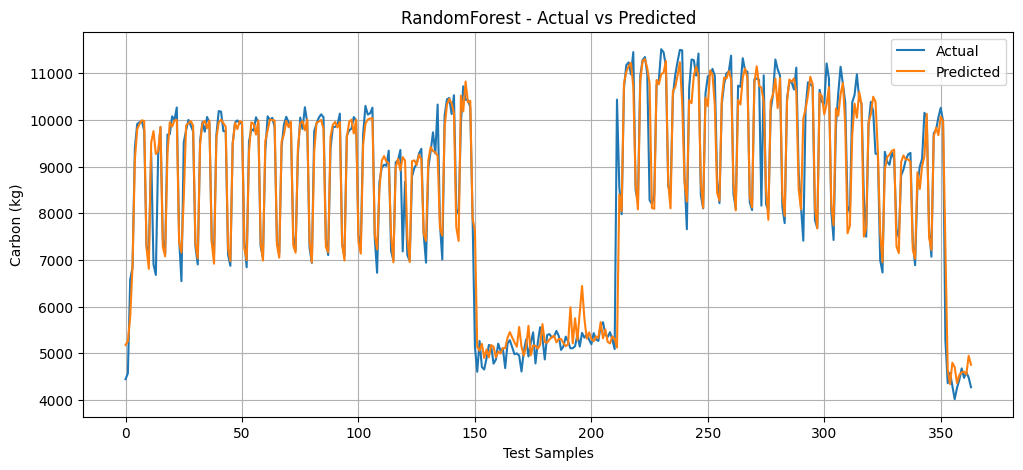

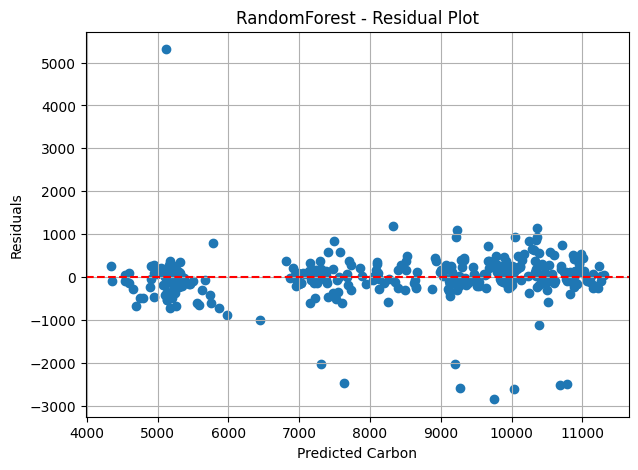


Top 10 Important Features

                 Feature  Importance
14               water_l    0.252274
0            day_of_week    0.226913
18             carbon_kg    0.139897
15              waste_kg    0.093446
10    hostellers_present    0.070580
16                lpg_kg    0.063422
12       electricity_kwh    0.048035
11  day_scholars_present    0.047109
5             avg_temp_c    0.020451
6             max_temp_c    0.014005


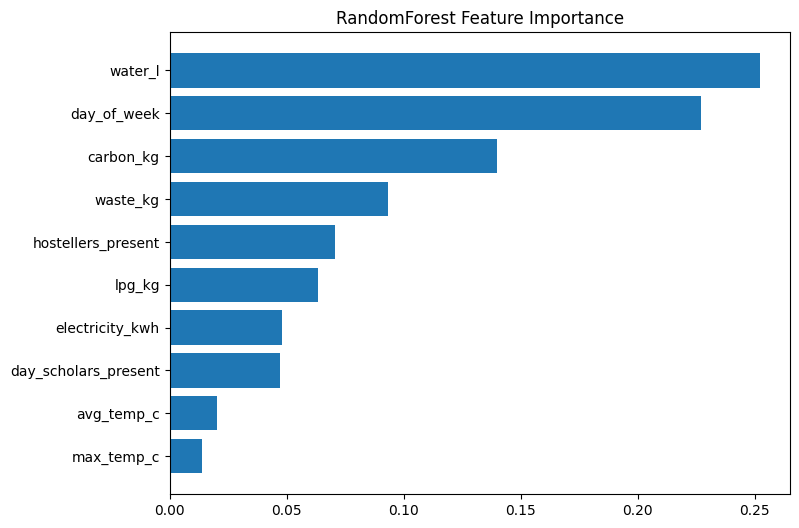

Training XGBoost model...
Best Parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
MAE  : 323.58
MSE  : 326776.98
RMSE : 571.64
R²   : 0.9278


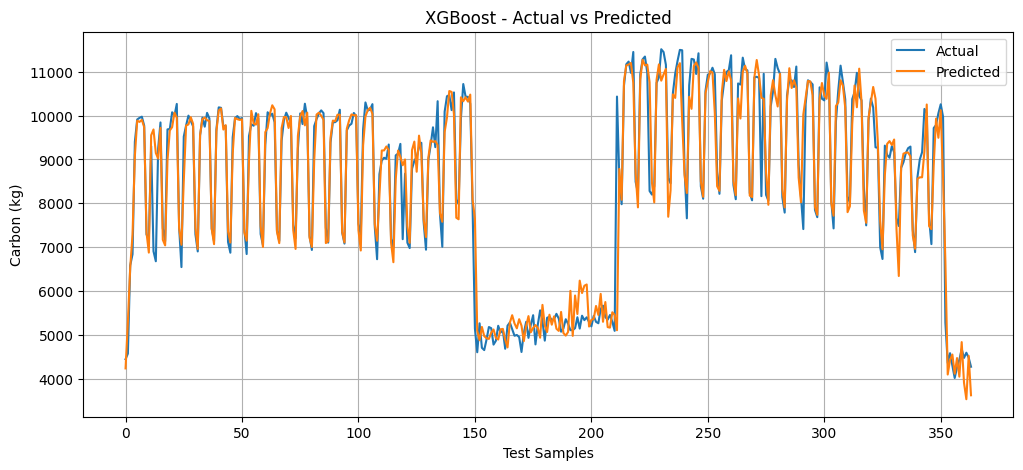

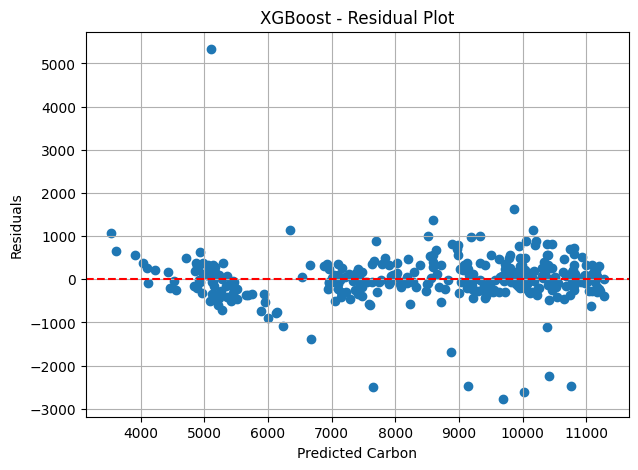


Top 10 Important Features

                 Feature  Importance
10    hostellers_present    0.879703
11  day_scholars_present    0.076983
0            day_of_week    0.016725
12       electricity_kwh    0.009944
18             carbon_kg    0.003538
3         academic_phase    0.002745
5             avg_temp_c    0.001680
6             max_temp_c    0.001462
14               water_l    0.001160
2                  month    0.001012


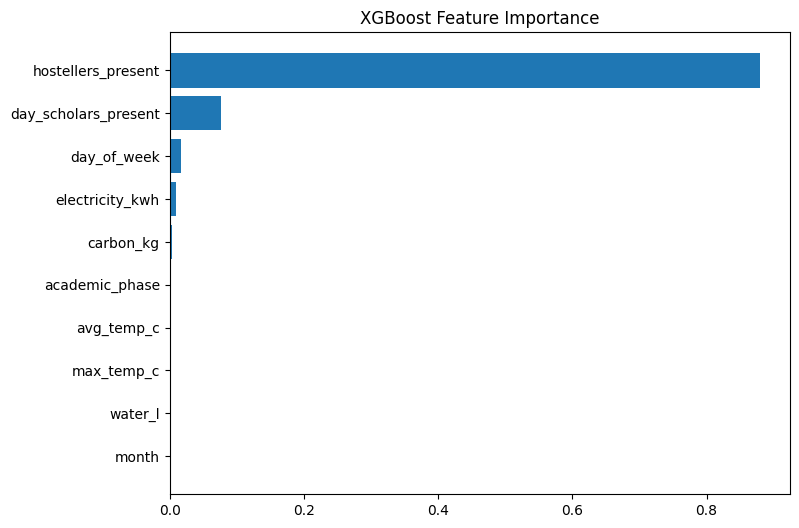

Training DecisionTree model...
Best Parameters : {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}
MAE  : 341.95
MSE  : 434570.53
RMSE : 659.22
R²   : 0.9040


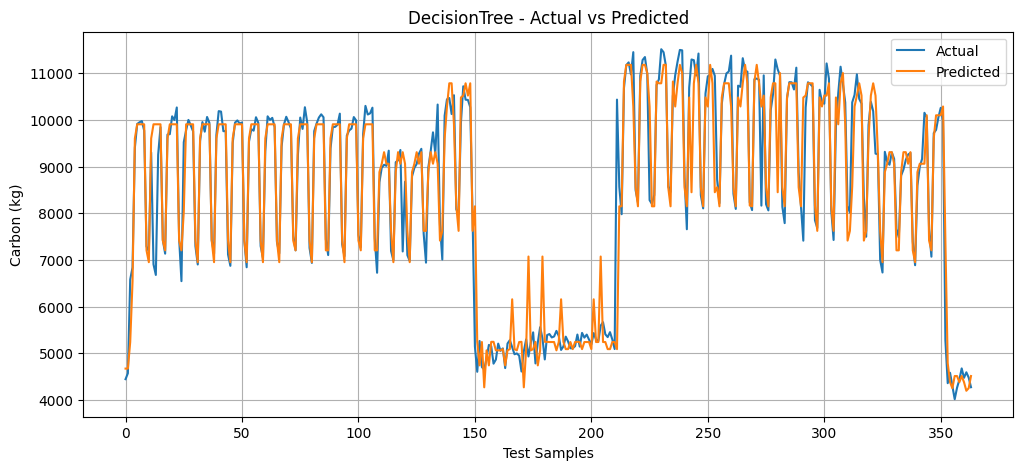

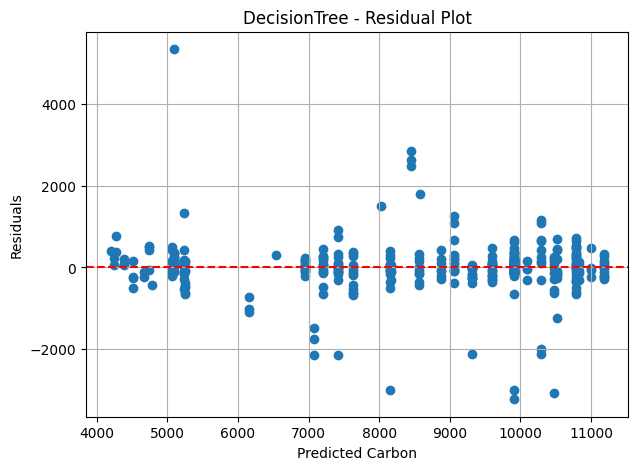


Top 10 Important Features

                Feature  Importance
14              water_l    0.664478
0           day_of_week    0.232322
12      electricity_kwh    0.038289
6            max_temp_c    0.025525
5            avg_temp_c    0.009648
2                 month    0.007093
3        academic_phase    0.006609
18            carbon_kg    0.005346
17  solar_kwh_generated    0.005050
15             waste_kg    0.004444


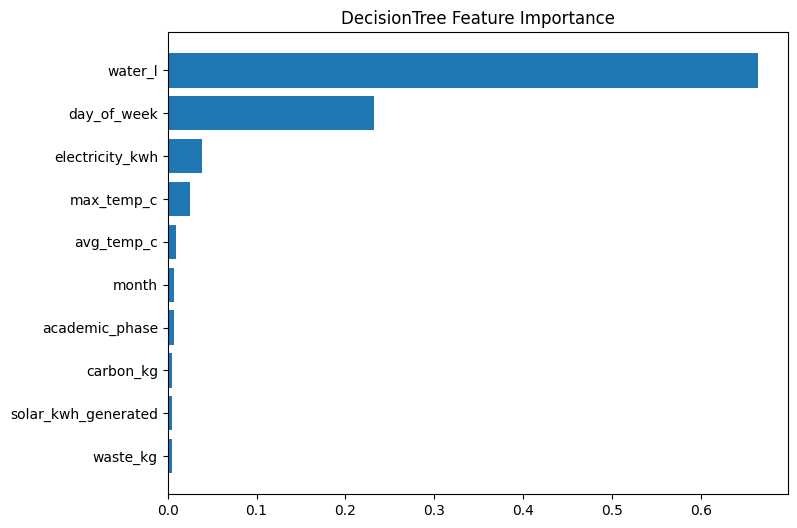


Training Completed!

Final Results

          Model         MAE            MSE        RMSE        R2  \
0  RandomForest  294.057648  310772.713661  557.469922  0.931378   
1       XGBoost  323.575631  326776.976425  571.644099  0.927844   
2  DecisionTree  341.952269  434570.533807  659.219640  0.904042   

                                     Best Parameters  
0  {'max_depth': 10, 'min_samples_leaf': 2, 'min_...  
1  {'colsample_bytree': 0.8, 'learning_rate': 0.1...  
2  {'max_depth': 6, 'min_samples_leaf': 2, 'min_s...  


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

results = []

for name, model, parameters in models:

    print(f"Training {name} model...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=parameters,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(xTrain, yTrain)

    bestModel = grid.best_estimator_

    # Prediction
    yPred = bestModel.predict(xTest)

    # Metrics
    mae = mean_absolute_error(yTest, yPred)
    mse = mean_squared_error(yTest, yPred)
    rmse = np.sqrt(mse)
    r2 = r2_score(yTest, yPred)

    # Save best model
    joblib.dump(bestModel, f"{name}_best_model.pkl")

    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Best Parameters": grid.best_params_
    })

    # Console Output
    print("Best Parameters :", grid.best_params_)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    # Actual vs Predicted Plot
    plt.figure(figsize=(12,5))

    plt.plot(yTest.values, label="Actual")
    plt.plot(yPred, label="Predicted")

    plt.title(f"{name} - Actual vs Predicted")
    plt.xlabel("Test Samples")
    plt.ylabel("Carbon (kg)")
    plt.legend()
    plt.grid(True)

    plt.show()
    # Residual Plot

    residuals = yTest - yPred

    plt.figure(figsize=(7,5))

    plt.scatter(yPred, residuals)

    plt.axhline(
        y=0,
        color="red",
        linestyle="--"
    )

    plt.title(f"{name} - Residual Plot")
    plt.xlabel("Predicted Carbon")
    plt.ylabel("Residuals")
    plt.grid(True)

    plt.show()

    # Feature Importance

    if hasattr(bestModel, "feature_importances_"):

        importance = pd.DataFrame({
            "Feature": xTrain.columns,
            "Importance": bestModel.feature_importances_
        })

        importance = importance.sort_values(
            by="Importance",
            ascending=False
        )

        print("\nTop 10 Important Features\n")
        print(importance.head(10))

        plt.figure(figsize=(8,6))

        plt.barh(
            importance["Feature"][:10],
            importance["Importance"][:10]
        )

        plt.gca().invert_yaxis()

        plt.title(f"{name} Feature Importance")

        plt.show()

print("\nTraining Completed!")

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

print("\nFinal Results\n")
print(results_df)

In [ ]:
import joblib

joblib.dump(best_model, "carbon_prediction_model.pkl")